# Feedforward Neural Network — Regression & Classification

This notebook trains a **Feedforward Neural Network (FFNN)** on the pre-processed student performance dataset.

| Task | Target | Metric |
|------|--------|--------|
| Regression | `exam_score` | RMSE, MAE, R² |
| Classification | `dropout_risk` | Accuracy, F1, ROC-AUC |

Mirrors the structure of `decision_trees.ipynb` for easy side-by-side comparison.

---
## 1 · Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PROCESSED_DIR = './processed'
OUT_DIR       = '../project/outputs/ffnn'
os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/models',  exist_ok=True)

print('Config OK. Output directory:', OUT_DIR)

Using device: cpu
Config OK. Output directory: ../project/outputs/ffnn


---
## 2 · Load Pre-Processed Artefacts

In [2]:
# # Feature matrices (scaled — essential for neural networks)
# X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train_scaled.csv', index_col=0)
# X_val   = pd.read_csv(f'{PROCESSED_DIR}/X_val_scaled.csv',   index_col=0)
# X_test  = pd.read_csv(f'{PROCESSED_DIR}/X_test_scaled.csv',  index_col=0)
#
# # Regression targets
# y_reg_train = pd.read_csv(f'{PROCESSED_DIR}/y_reg_train.csv', index_col=0).squeeze()
# y_reg_val   = pd.read_csv(f'{PROCESSED_DIR}/y_reg_val.csv',   index_col=0).squeeze()
# y_reg_test  = pd.read_csv(f'{PROCESSED_DIR}/y_reg_test.csv',  index_col=0).squeeze()
#
# # Classification targets
# y_clf_train = pd.read_csv(f'{PROCESSED_DIR}/y_clf_train.csv', index_col=0).squeeze()
# y_clf_val   = pd.read_csv(f'{PROCESSED_DIR}/y_clf_val.csv',   index_col=0).squeeze()
# y_clf_test  = pd.read_csv(f'{PROCESSED_DIR}/y_clf_test.csv',  index_col=0).squeeze()
#
# feature_names = pd.read_csv(f'{PROCESSED_DIR}/feature_list.csv')['feature'].tolist()
#
# print('Loaded splits:')
# for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
#     print(f'  {name:5s}  {arr.shape[0]:6d} rows  {arr.shape[1]} features')
# print(f'\nRegression target  — mean={y_reg_train.mean():.2f}, std={y_reg_train.std():.2f}')
# print(f'Classification target — class balance {y_clf_train.value_counts(normalize=True).round(3).to_dict()}')

## 2 · Load Pre-Processed Artefacts
# Feature matrices (scaled — essential for neural networks)
X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train_scaled.csv', index_col=0)
X_val = pd.read_csv(f'{PROCESSED_DIR}/X_val_scaled.csv', index_col=0)
X_test = pd.read_csv(f'{PROCESSED_DIR}/X_test_scaled.csv', index_col=0)

X_train = X_train.apply(pd.to_numeric, errors='coerce').astype(np.float32)
X_val = X_val.apply(pd.to_numeric, errors='coerce').astype(np.float32)
X_test = X_test.apply(pd.to_numeric, errors='coerce').astype(np.float32)

# Handle any NaNs introduced during coercion
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

# Regression targets
y_reg_train = pd.read_csv(f'{PROCESSED_DIR}/y_reg_train.csv', index_col=0).squeeze()
y_reg_val = pd.read_csv(f'{PROCESSED_DIR}/y_reg_val.csv', index_col=0).squeeze()
y_reg_test = pd.read_csv(f'{PROCESSED_DIR}/y_reg_test.csv', index_col=0).squeeze()

feature_names = pd.read_csv(f'{PROCESSED_DIR}/feature_list.csv')['feature'].tolist()

print('Loaded splits:')
for name, arr in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    print(f'  {name:5s}  {arr.shape[0]:6d} rows  {arr.shape[1]} features')

# 🔍 Sanity checks (VERY useful)
print('\nDtype check:', X_train.values.dtype)
print('NaNs in train:', np.isnan(X_train.values).sum())

print(f'\nRegression target  — mean={y_reg_train.mean():.2f}, std={y_reg_train.std():.2f}')

Loaded splits:
  Train   64000 rows  33 features
  Val      8000 rows  33 features
  Test     8000 rows  33 features

Dtype check: float32
NaNs in train: 0

Regression target  — mean=89.15, std=11.57


---
## 3 · Helper: Convert to PyTorch Tensors & DataLoaders

In [3]:
def make_loader(X, y, batch_size=512, shuffle=True, task='regression'):
    """Convert pandas DataFrames/Series to a PyTorch DataLoader."""
    X_t = torch.tensor(X.values, dtype=torch.float32)
    if task == 'regression':
        y_t = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    else:
        y_t = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 512
INPUT_DIM  = X_train.shape[1]
print(f'Input dimension: {INPUT_DIM}')

Input dimension: 33


---
## 4 · FFNN Architecture

In [4]:
class FFNN(nn.Module):
    """
    Configurable Feedforward Neural Network.

    Architecture (default):
        Input → FC(256) → BN → ReLU → Dropout(0.3)
               → FC(128) → BN → ReLU → Dropout(0.3)
               → FC(64)  → BN → ReLU → Dropout(0.2)
               → FC(32)  → ReLU
               → FC(output_dim)

    For regression  : output_dim=1, no final activation.
    For classification: output_dim=1, Sigmoid applied in loss (BCEWithLogitsLoss).
    """
    def __init__(self, input_dim, hidden_dims=(256, 128, 64, 32),
                 dropout_rates=(0.3, 0.3, 0.2, 0.0), output_dim=1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim, drop in zip(hidden_dims, dropout_rates):
            layers += [
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
            ]
            if drop > 0:
                layers.append(nn.Dropout(drop))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Quick sanity check
dummy = torch.randn(4, INPUT_DIM)
model_check = FFNN(INPUT_DIM)
print('Output shape:', model_check(dummy).shape)   # expect (4, 1)
total_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Output shape: torch.Size([4, 1])
Trainable parameters: 52,929


---
## 5 · Training Utility

In [5]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=100, patience=10, task='regression'):
    """
    Generic training loop with early stopping.

    Returns
    -------
    history : dict with 'train_loss' and 'val_loss' lists.
    """
    model.to(DEVICE)
    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(X_batch)
        train_loss = running_loss / len(train_loader.dataset)

        # ── Validate ────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(X_batch), y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if scheduler:
            scheduler.step(val_loss)

        # ── Early stopping ──────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  Early stop at epoch {epoch}  (best val loss={best_val_loss:.5f})')
                break

        if epoch % 10 == 0:
            print(f'  Epoch {epoch:4d} | train={train_loss:.5f} | val={val_loss:.5f}')

    model.load_state_dict(best_state)
    return history


def plot_loss_curve(history, title, save_path):
    plt.figure(figsize=(9, 4))
    plt.plot(history['train_loss'], label='Train loss')
    plt.plot(history['val_loss'],   label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

---
## 6 · Regression Task — Predict `exam_score`

### 6.1 · Hyperparameter Search (Hidden-dim variants)

In [6]:
reg_train_loader = make_loader(X_train, y_reg_train, BATCH_SIZE, shuffle=True,  task='regression')
reg_val_loader   = make_loader(X_val,   y_reg_val,   BATCH_SIZE, shuffle=False, task='regression')

configs = [
    {'hidden_dims': (128, 64, 32),       'lr': 1e-3, 'label': 'Shallow (128-64-32)'},
    {'hidden_dims': (256, 128, 64, 32),  'lr': 1e-3, 'label': 'Default (256-128-64-32)'},
    {'hidden_dims': (512, 256, 128, 64), 'lr': 5e-4, 'label': 'Wide (512-256-128-64)'},
]

results_search = []
for cfg in configs:
    print(f"\nTraining: {cfg['label']}")
    m = FFNN(INPUT_DIM, hidden_dims=cfg['hidden_dims'])
    opt = optim.Adam(m.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    h   = train_model(m, reg_train_loader, reg_val_loader,
                      nn.MSELoss(), opt, sch, epochs=150, patience=15)
    # Val RMSE
    m.eval()
    with torch.no_grad():
        preds = m(torch.tensor(X_val.values, dtype=torch.float32).to(DEVICE)).cpu().numpy().flatten()
    val_rmse = np.sqrt(mean_squared_error(y_reg_val, preds))
    results_search.append({'label': cfg['label'], 'val_rmse': val_rmse, 'model': m, 'history': h})
    print(f'  Val RMSE: {val_rmse:.3f}')

best_reg_result = min(results_search, key=lambda x: x['val_rmse'])
print(f"\nBest config: {best_reg_result['label']}  (Val RMSE={best_reg_result['val_rmse']:.3f})")
ffnn_reg = best_reg_result['model']


Training: Shallow (128-64-32)
  Epoch   10 | train=432.53238 | val=263.52996
  Epoch   20 | train=202.51238 | val=117.16792
  Epoch   30 | train=194.94526 | val=124.64799
  Epoch   40 | train=190.20409 | val=115.54997
  Epoch   50 | train=187.49298 | val=115.74430
  Early stop at epoch 58  (best val loss=115.05728)
  Val RMSE: 10.726

Training: Default (256-128-64-32)
  Epoch   10 | train=398.29333 | val=311.49141
  Epoch   20 | train=120.24869 | val=115.13135
  Epoch   30 | train=117.82342 | val=114.44299
  Early stop at epoch 36  (best val loss=114.15549)
  Val RMSE: 10.684

Training: Wide (512-256-128-64)
  Epoch   10 | train=1618.89976 | val=1379.26160
  Epoch   20 | train=129.08925 | val=116.83415
  Epoch   30 | train=118.56528 | val=114.03537
  Epoch   40 | train=114.98974 | val=115.11876
  Early stop at epoch 46  (best val loss=114.03505)
  Val RMSE: 10.679

Best config: Wide (512-256-128-64)  (Val RMSE=10.679)


### 6.2 · Training Loss Curve

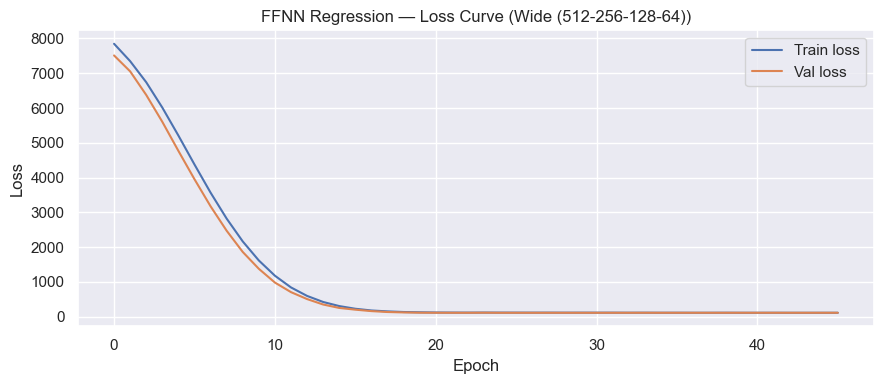

In [14]:
plot_loss_curve(
    best_reg_result['history'],
    f"FFNN Regression — Loss Curve ({best_reg_result['label']})",
    f'{OUT_DIR}/figures/reg_loss_curve.png'
)

### 6.3 · All Configs — Val RMSE Comparison

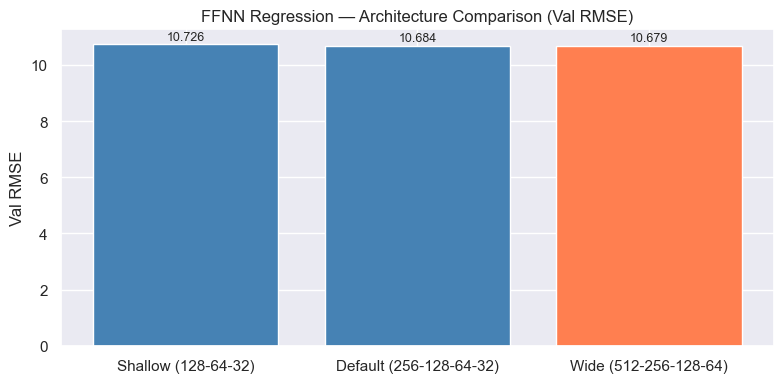

In [15]:
labels    = [r['label']    for r in results_search]
val_rmses = [r['val_rmse'] for r in results_search]

colors = ['steelblue' if l != best_reg_result['label'] else 'coral' for l in labels]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, val_rmses, color=colors)
plt.ylabel('Val RMSE')
plt.title('FFNN Regression — Architecture Comparison (Val RMSE)')
for bar, v in zip(bars, val_rmses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_arch_comparison.png', dpi=150)
plt.show()

### 6.4 · Evaluate on Test Set

In [16]:
ffnn_reg.eval()
with torch.no_grad():
    y_reg_pred = ffnn_reg(
        torch.tensor(X_test.values, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy().flatten()

rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
r2   = r2_score(y_reg_test, y_reg_pred)

print('─' * 35)
print(f'  RMSE : {rmse:.3f}')
print(f'  MAE  : {mae:.3f}')
print(f'  R²   : {r2:.4f}')
print('─' * 35)

───────────────────────────────────
  RMSE : 10.880
  MAE  : 8.947
  R²   : 0.1449
───────────────────────────────────


### 6.5 · Actual vs Predicted Plot

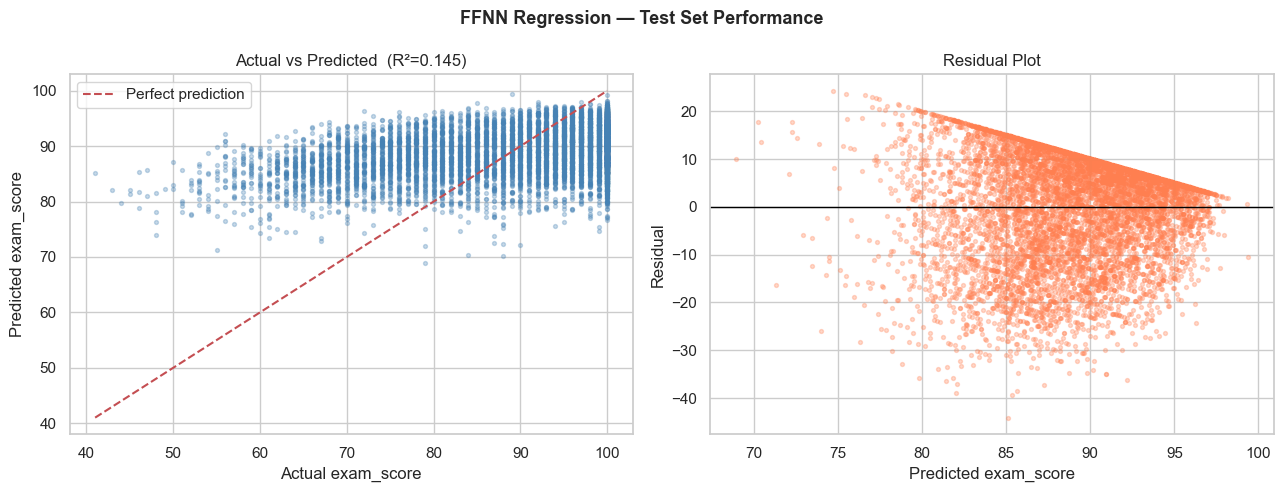

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, s=8, color='steelblue')
lims = [y_reg_test.min(), y_reg_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual exam_score')
axes[0].set_ylabel('Predicted exam_score')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_reg_test.values - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, alpha=0.3, s=8, color='coral')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted exam_score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.suptitle('FFNN Regression — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_actual_vs_predicted.png', dpi=150)
plt.show()

### 6.6 · Feature Importances via Permutation

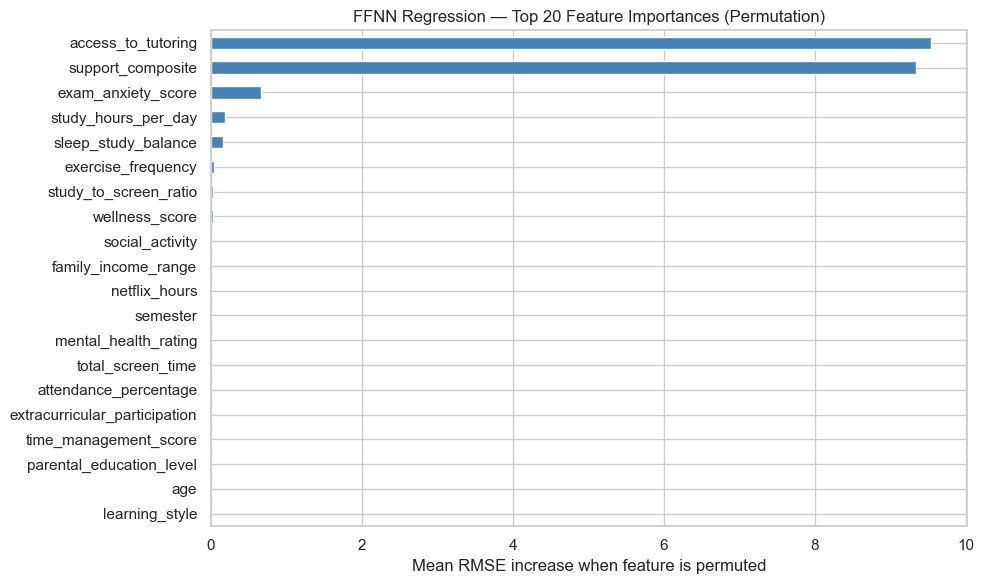

In [11]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

class FFNNSklearnWrapper(BaseEstimator, RegressorMixin):
    """Thin sklearn-compatible wrapper around our PyTorch FFNN."""
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        return self
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
            return self.model(t).cpu().numpy().flatten()

wrapped = FFNNSklearnWrapper(ffnn_reg)
perm = permutation_importance(
    wrapped, X_test.values, y_reg_test.values,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_root_mean_squared_error'
)

importances = pd.Series(perm.importances_mean, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Mean RMSE increase when feature is permuted')
plt.title('FFNN Regression — Top 20 Feature Importances (Permutation)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/reg_feature_importances.png', dpi=150)
plt.show()

### 6.7 · Save Regression Model

In [12]:
torch.save(ffnn_reg.state_dict(), f'{OUT_DIR}/models/ffnn_reg.pt')
print('Regression FFNN saved.')

Regression FFNN saved.


---
## 8 · Results Summary

In [13]:
summary = pd.DataFrame([
    {
        'Task':         'Regression (exam_score)',
        'Best Config':  best_reg_result['label'],
        'Test RMSE':    f'{rmse:.3f}',
        'Test MAE':     f'{mae:.3f}',
        'Test R²':      f'{r2:.4f}',
        'Test Acc':     '—',
        'Test F1':      '—',
        'Test AUC':     '—',
    },
])
display(summary)

print('\nAll figures saved to:', f'{OUT_DIR}/figures/')
print('All models saved to: ', f'{OUT_DIR}/models/')

,Task,Best Config,Test RMSE,Test MAE,Test R²,Test Acc,Test F1,Test AUC
0,Regression (exam_score),Wide (512-256-128-64),10.880,8.947,0.1449,—,—,—



All figures saved to: ../project/outputs/ffnn/figures/
All models saved to:  ../project/outputs/ffnn/models/
